In [2]:
!pip install pandas_datareader xgboost

In [3]:
import pandas as pd
import numpy as np
from pandas_datareader import data as pdr
import datetime

# --------------------------
# Config
# --------------------------
start = datetime.datetime(1995,1,1)
end   = datetime.datetime(2025,1,1)

fred_series = {
    "rate": "FEDFUNDS",
    "core_pce": "PCEPILFE",
    "unrate": "UNRATE",
    "indpro": "INDPRO",
    "gs10": "DGS10",
    "gs2": "DGS2",
    "breakeven_5y5y": "T5YIFR",
    "baa": "BAA",
    "aaa": "AAA"
}

df = pdr.DataReader(list(fred_series.values()), 'fred', start, end)
df.columns = fred_series.keys()
df = df.resample("M").mean()

/tmp/ipykernel_235/1155720652.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample("M").mean()


In [4]:
df

,rate,core_pce,unrate,indpro,gs10,gs2,breakeven_5y5y,baa,aaa
DATE,,,,,,,,,
1995-01-31,5.53,68.475,5.6,71.2734,7.779500,7.507000,NaN,9.08,8.46
1995-02-28,5.92,68.587,5.4,71.1930,7.469474,7.111579,NaN,8.85,8.26
1995-03-31,5.98,68.755,5.4,71.3113,7.204783,6.775652,NaN,8.70,8.12
1995-04-30,6.05,68.915,5.8,71.1882,7.062632,6.567895,NaN,8.60,8.03
1995-05-31,6.01,69.032,5.6,71.5378,6.632727,6.170909,NaN,8.20,7.65
...,...,...,...,...,...,...,...,...,...
2024-09-30,5.13,123.466,4.1,99.8084,3.723500,3.622500,2.248000,5.42,4.68
2024-10-31,4.83,123.832,4.1,99.4695,4.095455,3.972273,2.340455,5.63,4.95
2024-11-30,4.64,123.962,4.2,99.2925,4.355789,4.257368,2.254211,5.78,5.14


In [5]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================


# Inflation
df["core_pce_yoy"] = 100 * df["core_pce"].pct_change(12)

df["infl_momentum"] = df["core_pce_yoy"] - df["core_pce_yoy"].shift(3)

# Labor market
df["u_star"] = df["unrate"].rolling(60).mean()

df["unemp_gap"] = df["unrate"] - df["u_star"]

# Financial conditions
df["yield_slope"] = df["gs10"] - df["gs2"]

df["credit_spread"] = df["baa"] - df["aaa"]

# Policy memory
df["d_rate"] = df["rate"].diff()

df["change_flag"] = (df["d_rate"].abs() > 0.001).astype(int)

df["change_group"] = df["change_flag"].cumsum()

df["months_since_change"] = df.groupby("change_group").cumcount()

df.drop(columns=["change_flag","change_group"], inplace=True)


# ==========================================================
# CREATE LAG FEATURES
# ==========================================================

base_features = [
    "core_pce_yoy",
    "infl_momentum",
    "unemp_gap",
    "yield_slope",
    "credit_spread",
    "breakeven_5y5y",
    "rate",
    "months_since_change"
]

for col in base_features:

    for l in [1,3,6]:

        df[f"{col}_lag{l}"] = df[col].shift(l)


# ==========================================================
# FINAL CLEANUP
# ==========================================================

df = df.dropna().copy()

print("Total columns:", len(df.columns))
print("Lag features created:")
print([c for c in df.columns if "lag" in c])

Total columns: 41
Lag features created:
['core_pce_yoy_lag1', 'core_pce_yoy_lag3', 'core_pce_yoy_lag6', 'infl_momentum_lag1', 'infl_momentum_lag3', 'infl_momentum_lag6', 'unemp_gap_lag1', 'unemp_gap_lag3', 'unemp_gap_lag6', 'yield_slope_lag1', 'yield_slope_lag3', 'yield_slope_lag6', 'credit_spread_lag1', 'credit_spread_lag3', 'credit_spread_lag6', 'breakeven_5y5y_lag1', 'breakeven_5y5y_lag3', 'breakeven_5y5y_lag6', 'rate_lag1', 'rate_lag3', 'rate_lag6', 'months_since_change_lag1', 'months_since_change_lag3', 'months_since_change_lag6']



HORIZON: 1 months
Total samples: 258

Full dataset class counts:
target
2.0    120
0.0     70
1.0     68
Name: count, dtype: int64

Top Features by Permutation Importance
infl_momentum_lag1          4.000000e-02
core_pce_yoy_lag6           4.000000e-02
rate_lag6                   3.666667e-02
infl_momentum_lag3          3.000000e-02
breakeven_5y5y_lag1         2.833333e-02
breakeven_5y5y_lag3         2.666667e-02
credit_spread_lag1          2.333333e-02
breakeven_5y5y_lag6         2.333333e-02
credit_spread_lag6          2.166667e-02
rate_lag3                   2.166667e-02
rate_lag1                   2.000000e-02
credit_spread_lag3          1.833333e-02
infl_momentum_lag6          1.833333e-02
unemp_gap_lag6              1.500000e-02
yield_slope_lag6            1.166667e-02
months_since_change_lag3    6.666667e-03
yield_slope_lag1            6.666667e-03
core_pce_yoy_lag1           5.000000e-03
core_pce_yoy_lag3           5.000000e-03
yield_slope_lag3            3.333333e-03
months_s

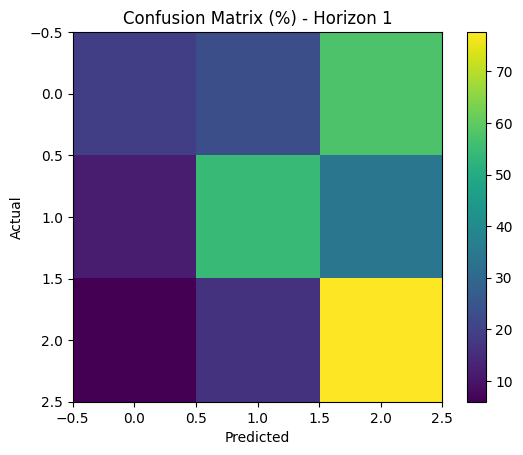

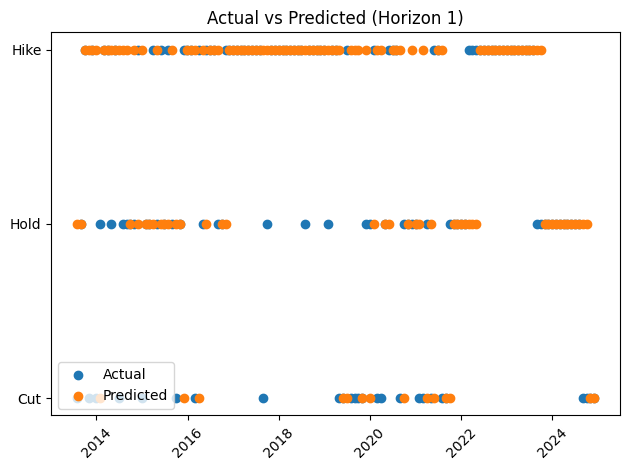


HORIZON: 3 months
Total samples: 258

Full dataset class counts:
target
2.0    134
0.0     87
1.0     37
Name: count, dtype: int64

Top Features by Permutation Importance
breakeven_5y5y_lag3         3.666667e-02
infl_momentum_lag3          2.500000e-02
months_since_change_lag1    2.333333e-02
infl_momentum_lag6          2.000000e-02
credit_spread_lag6          2.000000e-02
core_pce_yoy_lag3           1.666667e-02
unemp_gap_lag6              1.666667e-02
core_pce_yoy_lag1           1.666667e-02
breakeven_5y5y_lag6         1.333333e-02
rate_lag6                   1.333333e-02
credit_spread_lag1          1.333333e-02
yield_slope_lag3            1.000000e-02
breakeven_5y5y_lag1         8.333333e-03
credit_spread_lag3          8.333333e-03
infl_momentum_lag1          5.000000e-03
core_pce_yoy_lag6           3.333333e-03
rate_lag1                   3.333333e-03
unemp_gap_lag1              3.333333e-03
unemp_gap_lag3              3.333333e-03
yield_slope_lag1            3.333333e-03
months_s

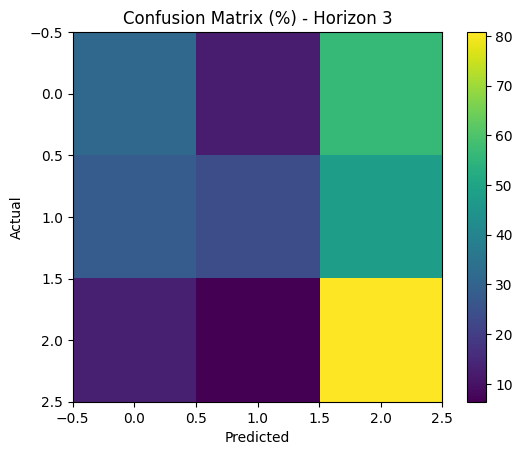

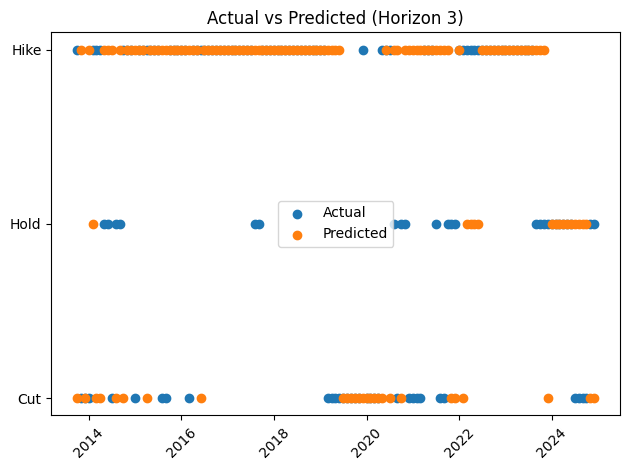


HORIZON: 6 months
Total samples: 258

Full dataset class counts:
target
2.0    144
0.0     83
1.0     31
Name: count, dtype: int64

Top Features by Permutation Importance
yield_slope_lag1            2.666667e-02
breakeven_5y5y_lag3         2.333333e-02
credit_spread_lag1          2.000000e-02
infl_momentum_lag6          1.833333e-02
yield_slope_lag3            1.500000e-02
infl_momentum_lag3          1.500000e-02
unemp_gap_lag3              1.166667e-02
breakeven_5y5y_lag6         1.166667e-02
rate_lag6                   1.166667e-02
core_pce_yoy_lag1           1.000000e-02
unemp_gap_lag1              1.000000e-02
infl_momentum_lag1          1.000000e-02
rate_lag3                   8.333333e-03
core_pce_yoy_lag6           8.333333e-03
rate_lag1                   8.333333e-03
unemp_gap_lag6              8.333333e-03
months_since_change_lag1    8.333333e-03
breakeven_5y5y_lag1         5.000000e-03
core_pce_yoy_lag3           3.333333e-03
yield_slope_lag6            1.666667e-03
months_s

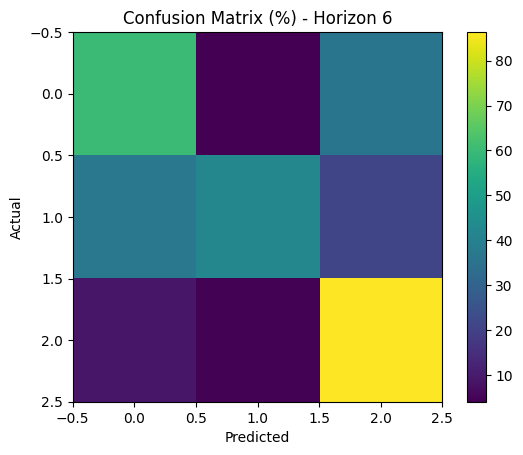

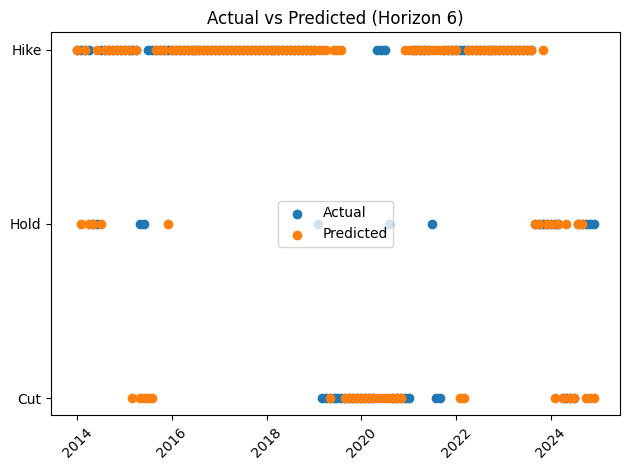

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.inspection import permutation_importance
from collections import Counter


# ==========================================================
# TARGET FUNCTION
# ==========================================================

def create_target(df, horizon):

    future_change = df["rate"].shift(-horizon) - df["rate"]

    target = np.ones(len(df))

    target[future_change > 0.001] = 2
    target[future_change < -0.001] = 0

    return target
'''

def create_target(df, horizon):
    future_change = df["rate"].shift(-horizon) - df["rate"]  # it will

    # target = np.Series(1, index=df.index)  # default = Hold (1)
    target = np.ones(len(df))  # default = Hold (1)
    target[future_change > 0.001] = 2  # Hike
    target[future_change < -0.001] = 0  # Cut

    return target
'''
# ==========================================================
# FEATURE LIST
# ==========================================================

def get_lag_features(df):

    features = [c for c in df.columns if "lag" in c]

    if len(features) == 0:
        raise ValueError("No lag features found.")

    return features


# ==========================================================
# PERMUTATION FEATURE SELECTION (RUN ONCE)
# ==========================================================

def permutation_feature_selection(train_df, features, top_k):

    X = train_df[features].values
    y = train_df["target"].values

    # This is below is default
    '''
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth= 8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
    '''
    # This is for experiment

    model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
    )


    '''
    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        random_state=42,
        eval_metric="mlogloss"
        )
    '''

    model.fit(X, y)

    perm = permutation_importance(
        model,
        X,
        y,
        n_repeats=5,   # reduced repeats
        random_state=42,
        n_jobs=-1
    )

    importance = pd.Series(
        perm.importances_mean,
        index=features
    ).sort_values(ascending=False)

    print("\nTop Features by Permutation Importance")
    print(importance)

    selected_features = importance.head(top_k).index.tolist()

    print("\nSelected Top Features:")
    print(selected_features)

    # return selected_features

    return importance.head(top_k).index.tolist()



# ==========================================================
# ROLLING CLASSIFICATION
# ==========================================================

def rolling_classification_xgb(df, horizon, top_k):

    df_local = df.copy()

    df_local["target"] = create_target(df_local, horizon)

    df_local = df_local.dropna()

    features = get_lag_features(df_local)

    train_window = 120

    preds = []
    actual = []
    dates = []

    # ------------------------------------------------------
    # FEATURE SELECTION ONLY ON FIRST WINDOW
    # ------------------------------------------------------

    first_train = df_local.iloc[:train_window]

    selected_features = permutation_feature_selection(
        first_train,
        features,
        top_k
    )

    X = df_local[selected_features].values
    y = df_local["target"].values
    dates_all = df_local.index

    # ------------------------------------------------------
    # ROLLING MODEL
    # ------------------------------------------------------

    for start in range(len(df_local) - train_window - horizon):

        train_start = start
        train_end = start + train_window

        test_index = train_end + horizon - 1

        X_train = X[train_start:train_end]
        y_train = y[train_start:train_end]

        X_test = X[test_index].reshape(1, -1)

        '''
        model = RandomForestClassifier(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
        '''

        model = XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=3,
            random_state=42,
            eval_metric="mlogloss"
            )

        model.fit(X_train, y_train)

        #pred = model.predict(X_test)[0]
        pred = np.argmax(model.predict_proba(X_test))

        preds.append(pred)
        actual.append(y[test_index])
        dates.append(dates_all[test_index])

    return np.array(preds), np.array(actual), dates


# ==========================================================
# DIAGNOSTICS
# ==========================================================

def detailed_diagnostics_xgb(df, horizon, top_k):

    df_local = df.copy()

    df_local["target"] = create_target(df_local, horizon)

    df_local = df_local.dropna()

    print("\n========================================")
    print(f"HORIZON: {horizon} months")
    print("========================================")

    print("Total samples:", len(df_local))

    print("\nFull dataset class counts:")
    print(df_local["target"].value_counts())

    preds, actual, dates = rolling_classification_xgb(df, horizon, top_k)

    print("\nOut-of-sample samples:", len(actual))

    print("\nActual class counts:")
    print(Counter(actual))

    print("\nPredicted class counts:")
    print(Counter(preds))

    # -------------------------------------------------
    # METRICS
    # -------------------------------------------------

    print("\nOverall Accuracy:", accuracy_score(actual, preds))

    print("Macro Precision:", precision_score(actual, preds, average="macro", zero_division=0))

    print("Macro Recall:", recall_score(actual, preds, average="macro", zero_division=0))

    print("Macro F1:", f1_score(actual, preds, average="macro", zero_division=0))

    print("\nClassification Report:")
    print(classification_report(
        actual,
        preds,
        target_names=["Cut", "Hold", "Hike"],
        zero_division=0)
    )

  #  print(classification_report(actual, preds, zero_division=0))
  #  print("\nClassification Report:")



    # -------------------------------------------------
    # CONFUSION MATRIX
    # -------------------------------------------------

    cm = confusion_matrix(actual, preds)

    print("\nConfusion Matrix (Counts)")
    print(cm)

    cm_percent = cm.astype(float) / cm.sum(axis=1)[:, None] * 100

    print("\nConfusion Matrix (%)")
    print(np.round(cm_percent, 2))

    plt.figure()

    plt.imshow(cm_percent)

    plt.title(f"Confusion Matrix (%) - Horizon {horizon}")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.colorbar()

    plt.show()

    # -------------------------------------------------
    # SCATTER PLOT
    # -------------------------------------------------

    plt.figure()

    plt.scatter(dates, actual, label="Actual")
    plt.scatter(dates, preds, label="Predicted")

    plt.title(f"Actual vs Predicted (Horizon {horizon})")

    plt.yticks([0, 1, 2], ["Cut", "Hold", "Hike"])

    plt.xticks(rotation=45)

    plt.legend()

    plt.tight_layout()

    plt.show()


# ==========================================================
# RUN MODEL
# ==========================================================

TOP_K = 10

for h in [1, 3, 6]:

    detailed_diagnostics_xgb(df, h, TOP_K)